In [1]:
import sys
sys.path.append("..")

In [2]:
# downloading dataset
import json
import os
import urllib

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data =response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8")as file:
            file.write(text_data)
    else:
        with open(file_path, "r",encoding="utf-8") as file:
            text_data =file.read()

    with open(file_path, "r") as file:
        data =json.load(file)
    return data

file_path ="instruction-data.json"
url = ("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
"/main/ch07/01_main-chapter-code/instruction-data.json"
)
data =download_and_load_file(file_path, url)
print("No. of entries: ", len(data))
print("Example entry: \n", data[567])


No. of entries:  1100
Example entry: 
 {'instruction': 'Identify the adjective in the sentence.', 'input': 'The red car sped down the road.', 'output': "The adjective in the sentence is 'red'."}


In [3]:
def format_input(entry):
    instruction_text= (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text =(
        f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )
    return instruction_text +input_text

In [4]:
# testing
model_input =format_input(data[567])
desired_response =f"\n\n### Response:\n{data[567]['output']}"
print(model_input +desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the adjective in the sentence.

### Input:
The red car sped down the road.

### Response:
The adjective in the sentence is 'red'.


In [5]:
# partioning dataste
train_portion = int(len(data)* 0.85)
test_portion =int(len(data)* 0.1)
val_portion =len(data) -train_portion -test_portion

train_data =data[:train_portion]
test_data = data[train_portion :train_portion+ test_portion]
val_data =data[train_portion +test_portion:]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


In [6]:
# instruction dataset class
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data,tokenizer):
        self.data =data
        self.encoded_texts =[]

        # pretokenizing text
        for entry in data:
            instruction_plus_input =format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text =instruction_plus_input +response_text
            self.encoded_texts.append(tokenizer.encode(full_text))

    def __getitem__(self, index):
        return self.encoded_texts[index]
    def __len__(self):
        return len(self.data)

In [7]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [8]:
# pads training examples in each batch to the same length while allowing different batches to have diff lengths
def custom_collate_draft_1(batch, pad_token_id=50256, device="cpu"):
    # longest sequence in batch
    batch_max_length =max(len(item) +1 for item in batch)   
    inputs_lst = []

    for item in batch:
        # padds and preparing inputs
        new_item=item.copy()
        new_item +=[pad_token_id]
        padded =(new_item +[pad_token_id]*(batch_max_length -len(new_item)))
        inputs =torch.tensor(padded[: -1])
        inputs_lst.append(inputs)

    inputs_tensor =torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [9]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]
batch = (inputs_1,inputs_2,inputs_3)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [10]:
# generates target token ids from input token ids 
def custom_collate_draft_2(batch, pad_token_id=50256, device="cpu"):
    batch_max_length =max(len(item) +1 for item in batch)
    inputs_lst, targets_lst= [],[]

    for item in batch:
        new_item =item.copy()
        new_item +=[pad_token_id]
        padded =(new_item +[pad_token_id]*(batch_max_length -len(new_item)))
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        inputs_lst.append(inputs)
        targets_lst.append(targets)
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

inputs, targets =custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


In [11]:
# custom batch collate function
def custom_collate_fn(batch, pad_token_id=50256,ignore_index=-100, allowed_max_length=None,device="cpu"):
    batch_max_length =max(len(item) +1 for item in batch)
    inputs_lst,targets_lst =[],[]

    for item in batch:
        new_item =item.copy()
        new_item+= [pad_token_id]
        # pads sequences to max length
        padded= (new_item +[pad_token_id]*(batch_max_length -len(new_item)))

        # truncates last token for inputs
        inputs= torch.tensor(padded[: -1])
        targets= torch.tensor(padded[1:])

        # replaces all but first padding tokens in targets by ignore_index
        mask =targets ==pad_token_id
        indices =torch.nonzero(mask).squeeze()
        if indices.numel() >1:
            targets[indices[1: ]]= ignore_index

        if allowed_max_length is not None:
            inputs =inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor =torch.stack(inputs_lst).to(device)
    targets_tensor =torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [12]:
inputs, targets=custom_collate_fn(batch)
print("Inputs: ",inputs)
print("Targets:",targets)

Inputs:  tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
Targets: tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [13]:
# ex     #prediction for 1st   & 2nd token
logits_1 =torch.tensor(([-1, 1], [-0.5, 1.5]))
targets_1 = torch.tensor([0,1])
loss_1 =torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

logits_2 = torch.tensor(
[[-1.0, 1.0],
[-0.5, 1.5],
[-0.5, 1.5]]
)
targets_2 = torch.tensor([0, 1, 1])
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(1.1269)
tensor(0.7936)


In [14]:
# replacing 3rd target token id with -100
targets_3 =torch.tensor([0, 1,-100])
loss_3 =torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3: ",loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3:  tensor(True)


In [15]:
device =torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ", device)

from functools import partial
customized_collate_fn = partial(custom_collate_fn,device=device,allowed_max_length=1024)

Device:  cpu


In [16]:
# initlializn data loaders
from torch.utils.data import DataLoader

num_workers =0
batch_size=8
torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(train_dataset,batch_size=batch_size,collate_fn=customized_collate_fn,shuffle=True,drop_last=True,num_workers=num_workers)
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(val_dataset,batch_size=batch_size, collate_fn=customized_collate_fn,shuffle=False, drop_last=False,num_workers=num_workers)
test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(test_dataset,batch_size=batch_size,collate_fn=customized_collate_fn,shuffle=False,drop_last=False,num_workers=num_workers)

In [17]:
print("Train loader")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])


torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 60]) torch.Size([8, 60])
torch.Size([8, 59]) torch.Size([8, 59])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 63]) torch.Size([8, 63])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 91]) torch.Size([8, 91])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 64]) torch.Size([8, 64])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 64]) torch.Size([8, 64])
torch.Size([8, 65]) torch.Size([8, 65])


In [18]:
# loading pretrained model
from pretraining.gpt_download import download_and_load_gpt2
from components.model import GPTModel
from utils.load_weight_gpt import load_weights_ingpt

BASE_CONFIG={
    "vocab_size": 50257, # Vocabulary size
    "context_length": 1024, # Context length
    "drop_rate": 0.0, # Dropout rate
    "qkv_bias": True
}
model_configs = {
"gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
"gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
"gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
"gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
CHOOSE_MODEL = "gpt2-small (124M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

model =GPTModel(BASE_CONFIG)
load_weights_ingpt(model, params)
model.eval()

torch version 2.12.1
tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
Attention weights:  tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)
Attention weights:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum:  tensor(1.)
Attention weights:  tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum:  tensor(1.)
tensor([0.4419, 0.6515, 0.5683])
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [19]:
torch.manual_seed(123)
input_text =format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [20]:
from components.pretrain import token_ids_to_text, text_to_token_ids, generate

token_ids =generate(model=model, idx=text_to_token_ids(input_text,tokenizer), max_new_tokens=35, context_size=BASE_CONFIG["context_length"], eos_id=256)

generated_text =token_ids_to_text(token_ids, tokenizer)
response_text =generated_text[len(input_text): ].strip()
print(response_text)

### Instruction:

Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Instruction:

Convert the active


In [21]:
from components.pretrain import calc_loss_loader, train_model_simple

model.to(device)
torch.manual_seed(123)

with torch.no_grad():
    train_loss =calc_loss_loader(train_loader, model,device, num_batches=5)
    val_loss =calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss: ", train_loss)
print("Validation loss: ", val_loss)

Training loss:  4.1671370506286625
Validation loss:  4.050931739807129


In [22]:
# instruction finetuning pretrained llm
import time
import torch
start_time =time.time()
torch.manual_seed(123)
optimizer =torch.optim.AdamW(model.parameters(),lr=0.00005, weight_decay=0.1)
num_epcohs =2

train_losses, val_losses,tokens_seen =train_model_simple(model, train_loader,val_loader, optimizer, device=device,num_epochs=num_epcohs,eval_freq=5, eval_iter=5,start_context=format_input(val_data[0]), tokenizer=tokenizer)

end_time =time.time()
execution_time_minutes= (end_time- start_time)/60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 3.119, Val loss 3.069
Ep 1 (Step 000005): Train loss 1.696, Val loss 1.570
Ep 1 (Step 000010): Train loss 1.096, Val loss 1.164
Ep 1 (Step 000015): Train loss 1.053, Val loss 1.083
Ep 1 (Step 000020): Train loss 0.970, Val loss 1.038
Ep 1 (Step 000025): Train loss 0.920, Val loss 1.002
Ep 1 (Step 000030): Train loss 0.960, Val loss 0.978
Ep 1 (Step 000035): Train loss 0.877, Val loss 0.951
Ep 1 (Step 000040): Train loss 0.847, Val loss 0.943
Ep 1 (Step 000045): Train loss 0.777, Val loss 0.925
Ep 1 (Step 000050): Train loss 0.869, Val loss 0.911
Ep 1 (Step 000055): Train loss 0.923, Val loss 0.893
Ep 1 (Step 000060): Train loss 0.872, Val loss 0.877
Ep 1 (Step 000065): Train loss 0.800, Val loss 0.867
Ep 1 (Step 000070): Train loss 0.694, Val loss 0.860
Ep 1 (Step 000075): Train loss 0.706, Val loss 0.855
Ep 1 (Step 000080): Train loss 0.753, Val loss 0.847
Ep 1 (Step 000085): Train loss 0.680, Val loss 0.836
Ep 1 (Step 000090): Train loss 0.729, Val loss

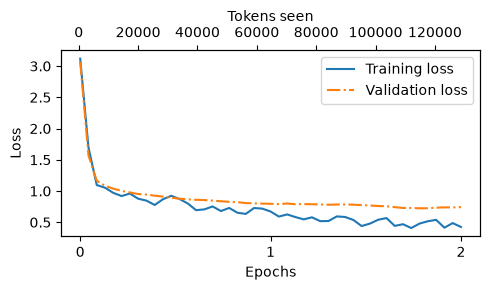

In [25]:
from components.pretrain import plot_losses
epochs_tensor =torch.linspace(0, num_epcohs,len(train_losses))
plot_losses(epochs_tensor,tokens_seen, train_losses, val_losses)